# **Improved Model Notebook Overview**

*Pipeline of setting up, building, training, testing, analyzing my improved model based on the findings of the basic*

---

In [1]:
import os
import torch
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sqlalchemy import create_engine
from dotenv import load_dotenv
import pickle

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

import sys
sys.path.insert(0, '../..')

from modeling.dataset import CarPriceDataset
from modeling.model import MLPCarPriceRegressionNet_V1, MLPCarPriceRegressionNet_V2
from modeling.train import train_model
from modeling.test import test_model
from modeling.plots_and_metrics import train_plot, train_metrics, test_plot, test_metrics, test_show_extreme_cases
from modeling.plots_and_metrics import plot_outlier_years, plot_outlier_km, plot_outlier_price, plot_outlier_by_manufacturer, plot_outlier_by_kw

from preprocessing.preprocess import PreProcessor
from preprocessing.clean import Cleaner
from preprocessing.impute import Imputer
from preprocessing.engineer import Engineer 

## **Cleaning & PreProcessing Pipeline**


In this improved model:

- Car price: 2M - 50M
- Car year: 2010 - 

---

In [2]:
FILENAME = 'car_details.csv'

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

df = pd.read_csv(f'../../data/raw/{FILENAME}')

cleaner = Cleaner(price_lower=2_000_000, price_upper = 50_000_000, year_lower = 2010, year_upper = None)
imputer = Imputer()
engineer = Engineer()

df = cleaner.clean(df)
summary = cleaner.get_summary()
display(summary)

df = imputer.impute(df)
summary = imputer.get_summary()
display(summary)

df = engineer.transform(df)
summary = engineer.get_summary()
display(summary)

df.to_csv(f'../../data/clean/car_details_improved.csv', index=False)

,Feature,Length Before,Length After,Dropped
0,Price,106447,75050,31397
1,Year,75050,67589,7461
2,Manufacturer/Model,67589,67456,133
3,Kilometers,67456,67447,9
4,Fuel Type,67447,67447,0
5,KW/LE,67447,66722,725
6,Condition,66722,66722,0
7,Trunk Capacity,66722,66720,2
8,Body Type,66720,66719,1
9,Seats,66719,66717,2


,Feature,Missing Before,Missing After,Imputed
0,Kilometers,1641,0,1641
1,Fuel Type,626,0,626
2,Trunk Capacity,6267,0,6267
3,Seats,703,0,703
4,Color,12808,0,12808
5,Engine Capacity,234,0,234
6,Drive Type,1327,0,1327
7,Transmission Type,3490,0,3490
8,Number of Gears,16765,0,16765


,Feature,Unqiue Before,Unqiue After
0,Fuel Type,12,7
1,Transmission Type,9,6
2,Color,76,38


## **Data Prep**

Includes:

- Splitting into train/val/test ~ 80/10/10 ratio
- Scaling & Encoding = fitting on only training set with PreProcessor
    - saved config
    - there is a human readable json config also, if debug needed
    - final numerical features, their scaler (type)
    - final categorical, their unique values, vocab size for future embeddings
- Model setup:
    - went for a wide but not too deep setup
        - input layer (around 80 neurons) -> 256
        - 2 hidden layers
        - output layer
    - activation function:
        - relu
    - no batchnorm
    - 0.2, 0.1 dropout in hidden layers
- Wrapping in datasets & dataloaders

---

In [3]:
df_train, df_temp = train_test_split(df, test_size = 0.2, random_state = 1)
df_val, df_test = train_test_split(df_temp, test_size = 0.5, random_state = 1)

preprocessor = PreProcessor()
preprocessor.fit(df_train)
preprocessor.save('../../workspace/config/improved_model.pkl', '../../workspace/config/improved_model.json')

model = MLPCarPriceRegressionNet_V2('../../workspace/config/improved_model.pkl')

X_num_train, X_cat_train, y_train = preprocessor.transform(df_train, is_training = True, include_target = True)
X_num_val, X_cat_val, y_val = preprocessor.transform(df_val, is_training = False, include_target = True)
X_num_test, X_cat_test, y_test = preprocessor.transform(df_test, is_training = False, include_target = True)

train_dataset = CarPriceDataset(X_num_train, X_cat_train, y_train)
val_dataset = CarPriceDataset(X_num_val, X_cat_val, y_val)
test_dataset = CarPriceDataset(X_num_test, X_cat_test, y_test)

batch_size = 64

dataloader_train = DataLoader(dataset = train_dataset, batch_size = batch_size, shuffle = True)
dataloader_val = DataLoader(dataset = val_dataset, batch_size = batch_size, shuffle = True)
dataloader_test = DataLoader(dataset = test_dataset, batch_size = batch_size, shuffle = False)

80


## **Training & Plotting training**

*Same as basic model but with more epoches*

- learning rate scheduling
- early stopping
- gradient clipping

Sometimes kind of unstable until learning rate modifier kicks in

---

Training on: cpu

Epoch [1/150] (LR: 0.000500)
  Train Loss: 9.4433
  Val Loss:   0.1396
  Val MAPE:   32.00%

Epoch [2/150] (LR: 0.000500)
  Train Loss: 0.8092
  Val Loss:   0.1157
  Val MAPE:   24.72%

Epoch [3/150] (LR: 0.000500)
  Train Loss: 0.6106
  Val Loss:   0.1709
  Val MAPE:   28.04%
  Early stopping counter: 1/40

Epoch [4/150] (LR: 0.000500)
  Train Loss: 0.4475
  Val Loss:   0.1165
  Val MAPE:   32.46%
  Early stopping counter: 2/40

Epoch [5/150] (LR: 0.000500)
  Train Loss: 0.3175
  Val Loss:   0.0570
  Val MAPE:   19.07%

Epoch [6/150] (LR: 0.000500)
  Train Loss: 0.2378
  Val Loss:   0.0602
  Val MAPE:   17.97%
  Early stopping counter: 1/40

Epoch [7/150] (LR: 0.000500)
  Train Loss: 0.1818
  Val Loss:   0.0549
  Val MAPE:   17.15%

Epoch [8/150] (LR: 0.000500)
  Train Loss: 0.1448
  Val Loss:   0.0490
  Val MAPE:   15.88%

Epoch [9/150] (LR: 0.000500)
  Train Loss: 0.1033
  Val Loss:   0.0460
  Val MAPE:   15.23%

Epoch [10/150] (LR: 0.000500)
  Train Loss: 0.0779
 

Metric,Value
BEST EPOCH,87.000000
BEST VAL LOSS,0.021179


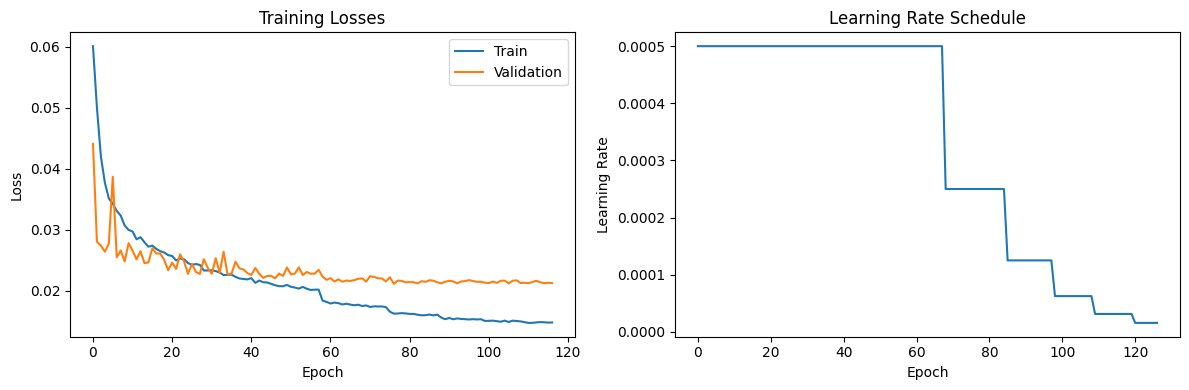

In [4]:
train = True

if train == True:
    history, model = train_model(
        model=model,
        train_loader=dataloader_train,
        val_loader=dataloader_val,
        epochs=150,
        learning_rate=0.0005,
        learning_rate_decay_factor=0.5
    )
    with open('../../workspace/train_histories/improved_model.pkl', 'wb') as f:
        pickle.dump(history, f)
    torch.save(model.state_dict(), '../../workspace/models/improved_model.pt')

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

with open('../../workspace/train_histories/improved_model.pkl', 'rb') as f:
    history = pickle.load(f)

display(train_metrics(history=history).style.hide(axis=0))
train_plot(history=history, skip_first_x = 10)

## **Testing & Plotting**

Much better predictions % wise, only a few real outliers

- Displaying more interpretable values
- visualizing MAPE 

Metric,Value,Description
MAE,1.09M Ft,Average absolute error
RMSE,2.04M Ft,Root mean squared error ~ penalizes outliers more
Mean APE,11.10%,Mean absolute percentage error ~ %
Median APE,8.38%,Median absolute percentage error ~ %
Within 10%,56.93%,Predictions with < 10% error
Within 20%,84.46%,Predictions with < 20% error
Within 30%,94.86%,Predictions with < 30% error


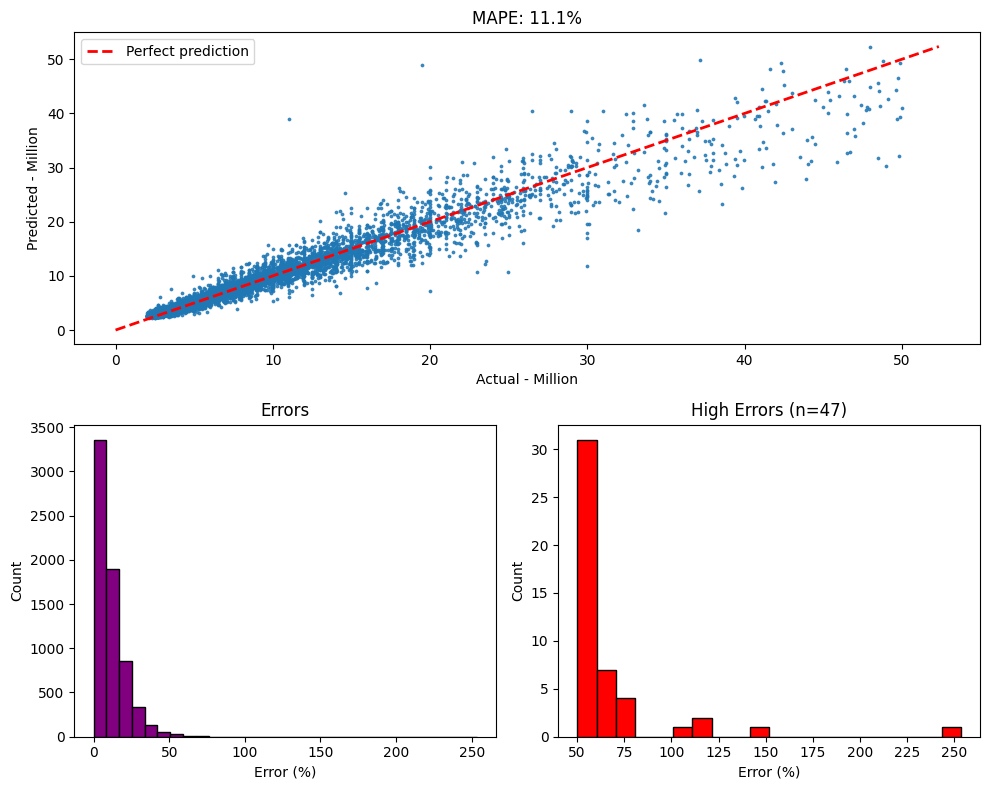

,price,predicted_price,percent_error,manufacturer,model,year,kw,kilometers
5171,11000000.0,38885256.0,253.502441,MERCEDES-BENZ,G-OSZTÁLY G 400,2022.92,243.0,99000.0
5740,19500000.0,48997468.0,151.269119,BMW,M SOROZAT M3,2013.42,677.0,1.0
5886,2800000.0,6026678.5,115.238594,BMW,X SOROZAT X3,2012.42,190.0,331000.0
3958,3500000.0,7509276.0,114.550804,LAND ROVER,RANGE ROVER,2011.17,230.0,198000.0
1194,4899900.0,9945405.0,102.971481,MERCEDES-BENZ,E-OSZTÁLY E 350,2014.58,185.0,253900.0


In [5]:
model.load_state_dict(torch.load('../../workspace/models/improved_model.pt'))

results = test_model(model, dataloader_test)
''' results = {
        'actual_prices' : actual_prices,
        'prediction_prices' : pred_prices,
        'percent_errors' : percent_errors,
        'metrics' : {
            'mae': mae,
            'rmse': rmse,
            'mape': mape,
            'median_ape': median_ape,
            'within_10': within_10,
            'within_20': within_20,
            'within_30': within_30
        }
    }
'''
display(test_metrics(results = results).style.hide(axis=0))
test_plot(results = results)
display(test_show_extreme_cases(results = results, df_test = df_test, extreme_threshhold=80))

## **Thoughts & Outlier searching**

From 16-17% MAPE in basic model -> 11% huge improvement but at the cost of sample size / market size

No more obvious outliers by any of the important features

*Plots thematic same as in basic model*
- Plots:
    - All of the plots have a similar theme, besides the manufacturer plot
    - First one shows the number of outliers in a certain range of the feature which can be misleading given we can't see the whole sample size in respect to the number of outliers *(and the sample distribution is not the same in each range)*
    - Second plot is more important because it shows what is the chance of a car being an outlier in a certain range of a feature
---

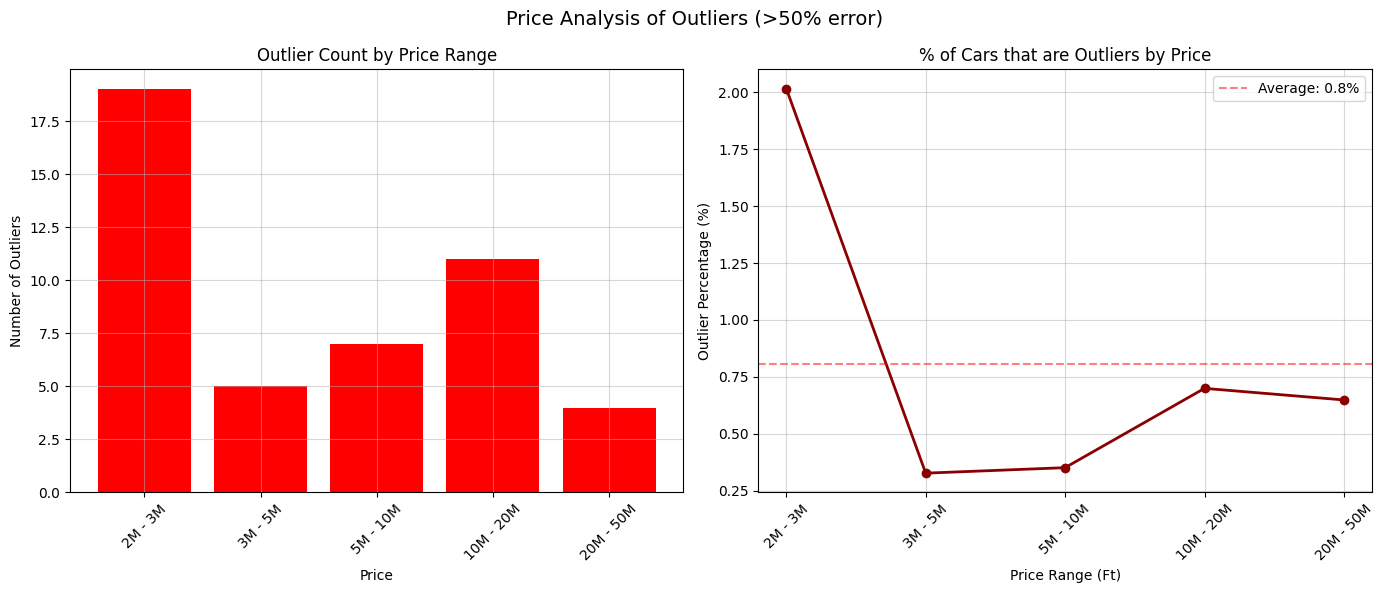

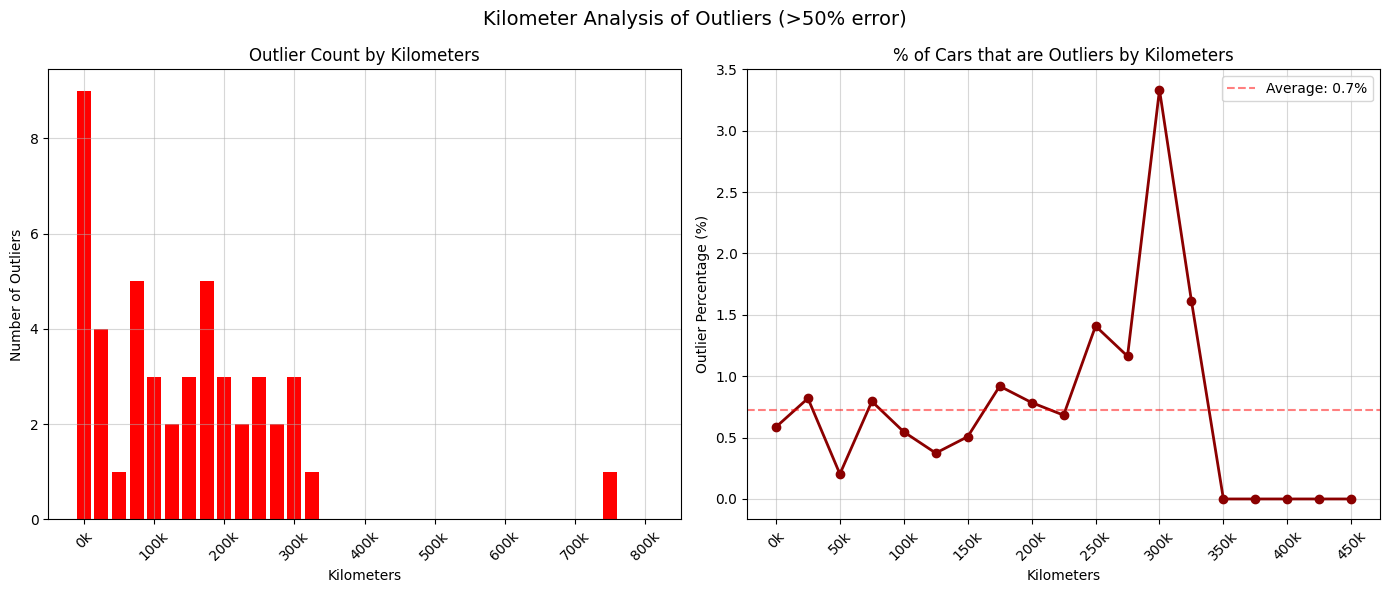

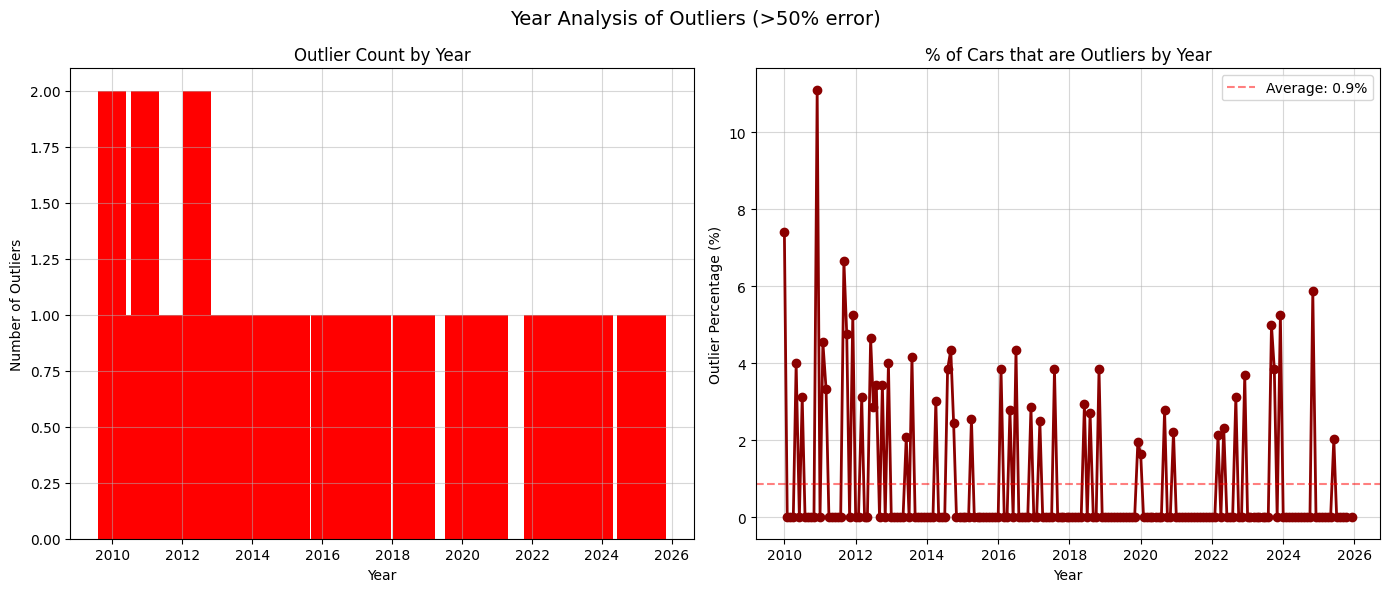

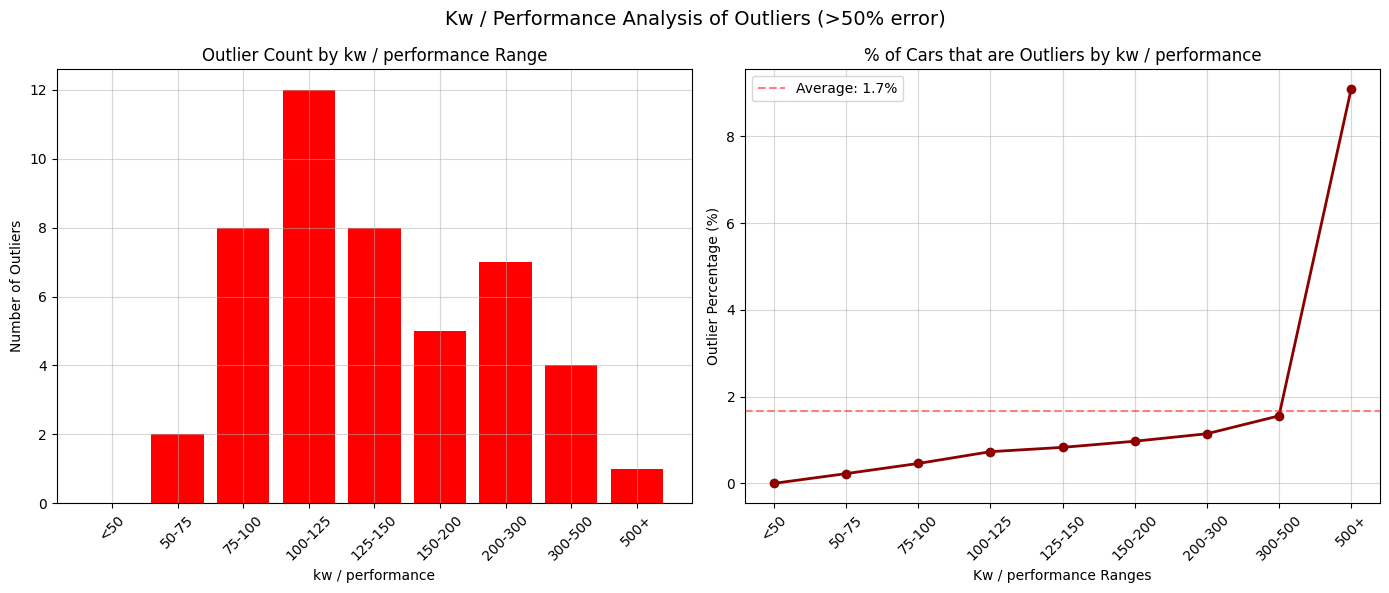

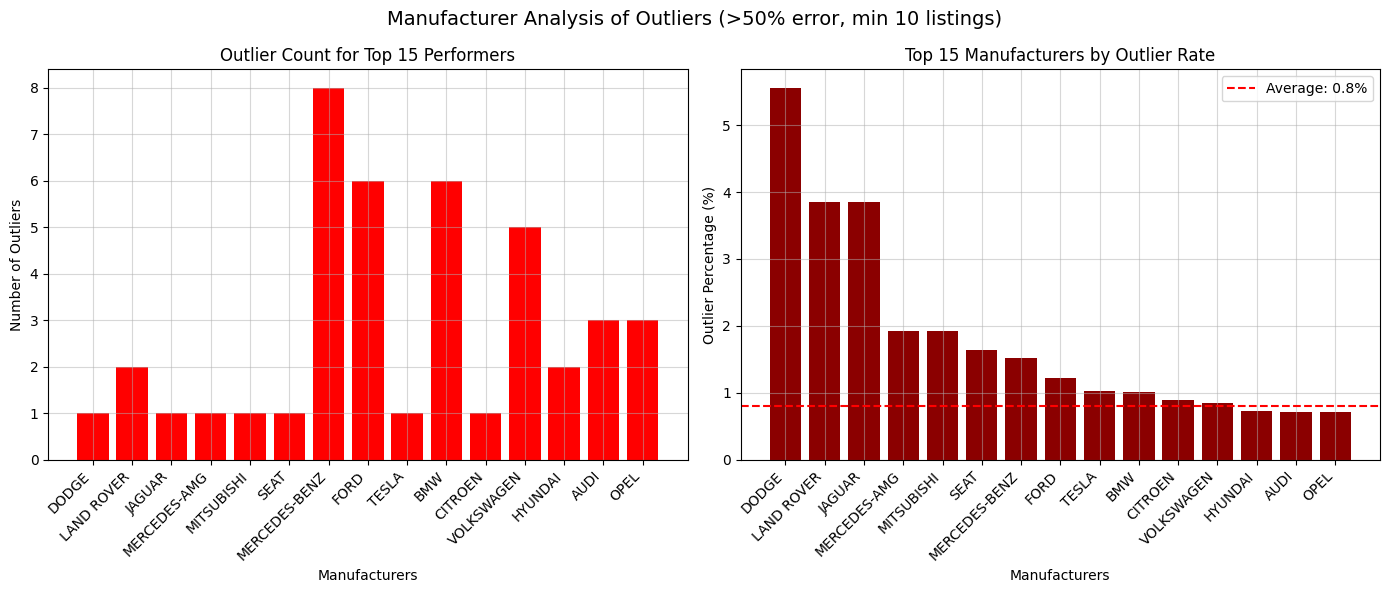

In [6]:
plot_outlier_price(results = results, df_test = df_test, threshold = 50, price_range='2M - 50M')
plot_outlier_km(results = results, df_test = df_test, threshold = 50)
plot_outlier_years(results = results, df_test = df_test, threshold = 50)
plot_outlier_by_kw(results = results, df_test = df_test, threshold = 50)
plot_outlier_by_manufacturer(results = results, df_test = df_test, threshold = 50, min_listings = 10)

## **Improvements & Thoughts & Tradeoffs**

Huge improvements from basic model, altough smaller market range coverage but i was just trying to achieve a lower mape while staying in a reasonable range in terms of price. This is probably the most reasonable balance & trade off

I experimented with other architectures as well, but wide and "shallow" networks worked best. The model could probably be improved by another 0.x percentage points with different optimizers, etc.

**Plan**:

- Scrape again and predict prices for some percentage of recent active listings 
- Cant predict all of them because I don't have enough "inactive listings" data yet ~ those that were removed from the site or sold


Ideally, it would be possible to check on Hasznaltauto.hu whether a listing was sold or simply removed. With enough time and really frequent scraping, the training data could consist only of sold listings, which I think would help tremendously with "real" price prediction at actual market level.
